# Fourier Neural Operator (FNO) in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library.

Example inspiration: examples/PDEs/Part_1_PINN_DiffusionEquation.ipynb

<img src="https://neuraloperator.github.io/dev/_images/fourier_layer.jpg" width="600"> 

The Fourier layer just consists of three steps:
- Fourier transform $\mathcal{F}$
- Linear transform on the lower Fourier modes $\mathbf{R}$
- Inverse Fourier transform $\mathcal{F}^{-1}$



## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [2]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Problem Setup

original source: https://deepxde.readthedocs.io/en/latest/demos/pinn_forward/diffusion.1d.html

**Diffusion equation**

$$\frac{\partial y}{\partial t} =\frac{\partial^2 y}{\partial x^2}-e^{-t}(sin(\pi x)-\pi^2 sin(\pi x))$$

$$x\in[-1,1]$$
$$t\in[0,1]$$

**Initial Condition:**

$$y(x,0)=sin(\pi x)$$

**Boundary Conditions:**

$$y(-1,t)=0$$
$$y(1,t)=0$$

**Exact solution:**

$$y(x,t)=e^{-t}sin(\pi x)$$

### Generate data of the exact solution

In [4]:
# exact solution y(x,t)
def f_real(x, t):
    return torch.exp(-t) * (torch.sin(np.pi * x))


# define range of the space and time variables:
x_min = -1
x_max = 1
t_min = 0
t_max = 1

# define number of spatial and temporal points
total_points_x = 200
total_points_t = 100

# generate samples of x, t
x = torch.linspace(x_min, x_max, total_points_x).view(-1, 1)
t = torch.linspace(t_min, t_max, total_points_t).view(-1, 1)

# Create the mesh of x, t
X, T = torch.meshgrid(x.squeeze(1), t.squeeze(1), indexing="ij")

# Evaluate exact solution y(x,t) on the mesh
y_real = f_real(X, T)

# data shapes
print(x.shape, t.shape)
print(X.shape, T.shape, y_real.shape)

torch.Size([200, 1]) torch.Size([100, 1])
torch.Size([200, 100]) torch.Size([200, 100]) torch.Size([200, 100])


In [5]:
# min and max values of the PDE solution
ymin = y_real.min()
ymax = y_real.max()
print(ymin, ymax)

tensor(-1.0000) tensor(1.0000)


### Plot the exact solution

In [6]:
def plot3D(X, T, y):
    #     2D
    fig = plt.figure()
    ax1 = fig.add_subplot(121)
    cm = ax1.contourf(T.numpy(), X.numpy(), y.numpy(), 20, cmap="viridis")
    fig.colorbar(cm, ax=ax1)  # Add a colorbar to a plot
    ax1.set_title("y(x,t)")
    ax1.set_xlabel("t")
    ax1.set_ylabel("x")
    ax1.set_aspect("equal")
    #     3D
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.plot_surface(T.numpy(), X.numpy(), y.numpy(), cmap="viridis")
    ax2.set_xlabel("t")
    ax2.set_ylabel("x")
    ax2.set_zlabel("y(x,t)")
    fig.tight_layout()

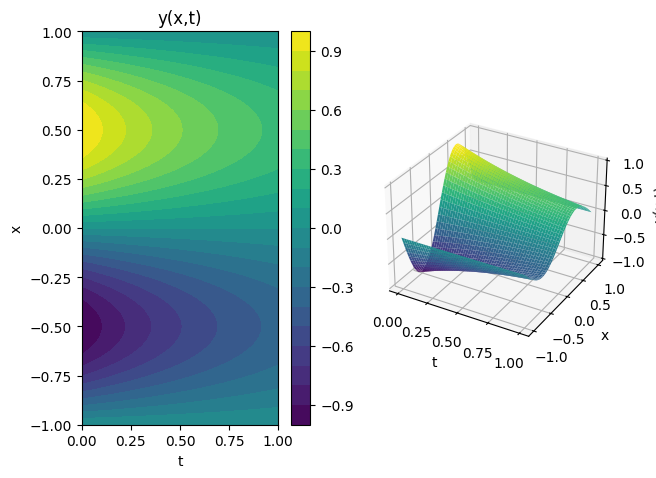

In [7]:
plot3D(X, T, y_real)

Insert training dataset for FNO, which is a sub-sampled 32x32 grid from the original 200X100 data

In [8]:
def make_fno_grid(nx, nt, requires_grad=False):
    x = torch.linspace(x_min, x_max, nx)
    t = torch.linspace(t_min, t_max, nt)
    X, T = torch.meshgrid(x, t, indexing="ij")
    Y = f_real(X, T)
    # Make grid tensors, FNO needs input shape: [batch_size, in_channels, nx, nt]
    xt_grid = torch.stack([X, T], dim=0).unsqueeze(0).float()  # [1, 2, nx, nt]
    y_grid = Y.unsqueeze(0).unsqueeze(0).float()
    # grad specified? (for training data)
    if requires_grad:
        xt_grid.requires_grad_(True)
    return xt_grid, y_grid


train_nx, train_nt = 32, 32
test_nx, test_nt = 16, 16

# 16x16 training grid
XT_train_grid, Y_train_grid = make_fno_grid(train_nx, train_nt, requires_grad=True)
# 32x32 testing grid
XT_test_grid, Y_test_grid = make_fno_grid(test_nx, test_nt, requires_grad=False)

### Visualise the training and testing grid. Takes a carterisan coordiante system

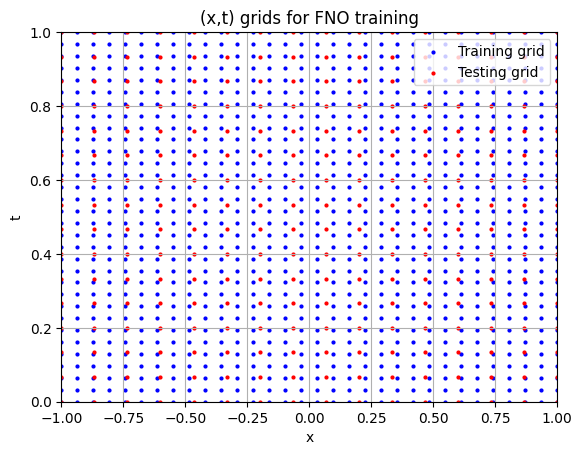

In [9]:
# visualize collocation points for 2D input space (x, t)

# --- Prepare Training Data ---
# Select the x and t coordinates (indices 0 and 1 in dim 1)
# and flatten the last two dimensions (nx * nt) into one vector.
# .squeeze() removes the batch dimension (size 1).
X_train_flat = XT_train_grid.squeeze(0)[0, :, :].flatten()
T_train_flat = XT_train_grid.squeeze(0)[1, :, :].flatten()

# --- Prepare Testing Data (assuming a similar structure) ---
X_test_flat = XT_test_grid.squeeze(0)[0, :, :].flatten()
T_test_flat = XT_test_grid.squeeze(0)[1, :, :].flatten()

# x-bounds: find the min/max ONLY in the testing x-coordinates
x_lb = torch.min(X_test_flat).item()
x_ub = torch.max(X_test_flat).item()

# t-bounds: find the min/max ONLY in the testing t-coordinates
t_lb = torch.min(T_test_flat).item()
t_ub = torch.max(T_test_flat).item()

# --- Plotting ---
plt.figure()
plt.scatter(
    X_train_flat.detach().numpy(),
    T_train_flat.detach().numpy(),
    s=4.0,
    c="blue",
    marker="o",
    label="Training grid",
)
plt.scatter(
    X_test_flat.detach().numpy(),
    T_test_flat.detach().numpy(),
    s=4.0,
    c="red",
    marker="o",
    label="Testing grid",
)

plt.title("(x,t) grids for FNO training")
# Assuming x_lb, x_ub, t_lb, t_ub are defined in your environment
plt.xlim(x_lb, x_ub)
plt.ylim(t_lb, t_ub)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("t")
plt.legend(loc="upper right")
plt.show()
# plt.show(block=True) # Usually only one plt.show() is needed
plt.show(block=True)

### Create Neuromancer datasets for FNO

In [10]:
from neuromancer.dataset import DictDataset

# turn on gradients for FNO
XT_train_grid = XT_train_grid.to(device)
Y_train_grid = Y_train_grid.to(device)

# Prepare FNO training and testing datasets
train_ds_fno = DictDataset(
    {"xt_grid": XT_train_grid, "y_grid": Y_train_grid}, name="fno_train"
)

train_loader_fno = torch.utils.data.DataLoader(
    train_ds_fno, batch_size=1, collate_fn=train_ds_fno.collate_fn, shuffle=False
)

# testing grid
test_ds_fno = DictDataset(
    {"xt_grid": XT_test_grid, "y_grid": Y_test_grid}, name="fno_test"
)
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno, batch_size=1, collate_fn=test_ds_fno.collate_fn, shuffle=False
)

### FNO added from neuralop library
May need a wrapper to provide data in the correct format


In [ ]:
# wrapper for neuralop.models import FNO
from neuromancer.modules.operators import FNO
from neuralop.utils import count_model_params
import sys

# FNO to to train the operator for the PDE problem bounded in the PDE domain
fno_model = FNO(
    n_modes=(8, 8),
    in_channels=2,
    out_channels=1,
    hidden_channels=12,
    projection_channel_ratio=2,
)
fno_model = fno_model.to(device)

# Count and display the number of parameters
n_params = count_model_params(fno_model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


In [13]:
from neuromancer.system import Node

# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["xt_grid"], ["y_hat_fno"], name="fno_model")

In [14]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['xt_grid']
symbolic outputs of the fno_node: ['y_hat_fno']


In [ ]:
# device checks
print(device)
print(train_ds_fno.datadict["y_grid"].device)
# evaluate forward pass on the train data
fno_model_out = fno_node(train_ds_fno.datadict)
fno_model_out["y_hat_fno"].shape

torch.Size([1, 1, 32, 32])

### Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

In [17]:
from neuromancer.constraint import Objective, variable

# define L2 loss objective for FNO
y_true = variable("y_grid")  # ground-truth field in your datadict
y_hat_fno = variable("y_hat_fno")  # output from the FNO node


In [18]:
# Approach 1: Using Constraint from Variables
l2_constraint = (y_hat_fno == y_true) ^ 2  # Eq constraint with quadratic penalty
l2_constraint.key = "l2norm"
l2_constraint.display_name = "l2norm_out"
# l2_obj = l2_constraint.minimize(metric=torch.mean, name="l2_fit")

In [19]:
# Approach 2: Using Objective
residual = y_hat_fno - y_true
l2_obj = Objective(residual**2, metric=torch.mean, name="l2_loss")

## H1 norm

$$
\|y - y_h\|_{H^1(\Omega)}^2
=
\|y - y_h\|_{L^2(\Omega)}^2
+
\|y_x - y_{h,x}\|_{L^2(\Omega)}^2
+
\|y_t - y_{h,t}\|_{L^2(\Omega)}^2.
$$



In [20]:
# xt_grid
xt = variable("xt_grid")

In [21]:
# define H1 loss objective for FNO
# slice later approach
# ensure grad on every batch (train/dev/test)
# xt = xt.requires_grad_(True)
grad_y_hat_xt = y_hat_fno.grad(xt)  # no allow_unused needed
grad_y_hat_x = grad_y_hat_xt[:, 0, :, :]
grad_y_hat_t = grad_y_hat_xt[:, 1, :, :]

grad_y_true_xt = y_true.grad(xt)  # no allow_unused needed
grad_y_true_x = grad_y_true_xt[:, 0, :, :]
grad_y_true_t = grad_y_true_xt[:, 1, :, :]

In [22]:
print(grad_y_true_t.requires_grad_)

<bound method Module.requires_grad_ of slice>


In [23]:
# define H1 loss objective for FNO
# slice first approach
# split xt_grid into spatial and temporal coordinates
x = xt[:, 0, :, :]
t = xt[:, 1, :, :]

# H^1-style constraint: penalize the field mismatch plus spatial/temporal gradients
grad_y_hat_x = y_hat_fno.grad(x)
grad_y_hat_t = y_hat_fno.grad(t)
# grad_y_true_x = y_true.grad(x)
# grad_y_true_t = y_true.grad(t)
grad_y_true_x = 0.0
grad_y_true_t = 0.0

In [24]:
# Approach 1: Using Constraint from Variables
# Derivative L2 error in x (seminorm)
x_seminorm = (grad_y_hat_x == grad_y_true_x) ^ 2
x_seminorm.key = "h1_x_seminorm"
# Derivative L2 error in t (seminorm)
t_seminorm = (grad_y_hat_t == grad_y_true_t) ^ 2
t_seminorm.key = "h1_t_seminorm"

In [25]:
# Approach 2: Using Objective
# Derivative residuals in x and t
res_grad_y_hat_x = grad_y_hat_x - grad_y_true_x
res_grad_y_hat_t = grad_y_hat_t - grad_y_true_t
h1_residual = residual**2 + res_grad_y_hat_x**2 + res_grad_y_hat_t**2
h1_obj = Objective(h1_residual, metric=torch.mean, name="h1_loss")

### Setup FNO problem and Trainer 

In [26]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
# objectives_fno = [l2_constraint, x_seminorm, t_seminorm]  # H1 loss for training FNO
objectives_fno = [l2_obj]  # L2 loss for training FNO
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[fno_node], loss=loss_fno, grad_inference=True)

### Show problem FNO

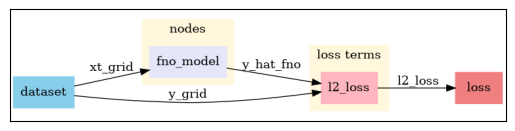

In [27]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO pirely data driven

In [28]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.Adam(problem_fno.parameters(), lr=0.001)
epochs = 500

#  Neuromancer trainer
trainer = Trainer(
    problem_fno.to(device),
    train_loader_fno,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="fno_train_loss",
    dev_metric="fno_train_loss",
    eval_metric="fno_train_loss",
    warmup=epochs,
    device=device,
)

In [29]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

epoch: 0  fno_train_loss: 0.21242564916610718
epoch: 10  fno_train_loss: 0.20890918374061584
epoch: 20  fno_train_loss: 0.2006150633096695
epoch: 30  fno_train_loss: 0.17094510793685913
epoch: 40  fno_train_loss: 0.08290320634841919
epoch: 50  fno_train_loss: 0.043625760823488235
epoch: 60  fno_train_loss: 0.027157334610819817
epoch: 70  fno_train_loss: 0.021217575296759605
epoch: 80  fno_train_loss: 0.01368982158601284
epoch: 90  fno_train_loss: 0.007215431891381741
epoch: 100  fno_train_loss: 0.00402083620429039
epoch: 110  fno_train_loss: 0.002674039453268051
epoch: 120  fno_train_loss: 0.0020781229250133038
epoch: 130  fno_train_loss: 0.001686434494331479
epoch: 140  fno_train_loss: 0.0014078167732805014
epoch: 150  fno_train_loss: 0.0012198596959933639
epoch: 160  fno_train_loss: 0.0010758888674899936
epoch: 170  fno_train_loss: 0.000954318093135953
epoch: 180  fno_train_loss: 0.0008503893623128533
epoch: 190  fno_train_loss: 0.0007578388322144747
epoch: 200  fno_train_loss: 0.000

<All keys matched successfully>

## Plots

In [30]:
# evaluate trained PINN on test data
fno_out = problem_fno.nodes[0].cpu()
y1 = fno_out(test_ds_fno.datadict)["y_hat_fno"]

# arrange data for plotting on the test grid
y_fno = y1.reshape(shape=[test_nx, test_nt]).transpose(1, 0).detach().cpu()

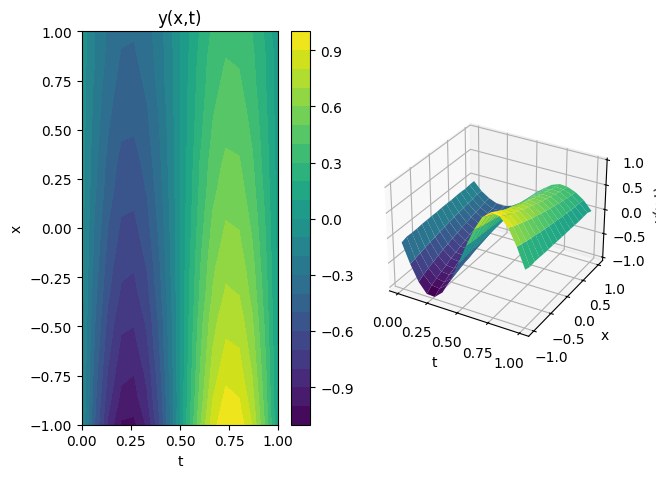

In [31]:
# plot FNO solution
# X-coordinates (index 0)
X_plot = XT_test_grid.squeeze(0)[0, :, :].detach().cpu()
# T-coordinates (index 1)
T_plot = XT_test_grid.squeeze(0)[1, :, :].detach().cpu()
plot3D(X_plot, T_plot, y_fno)

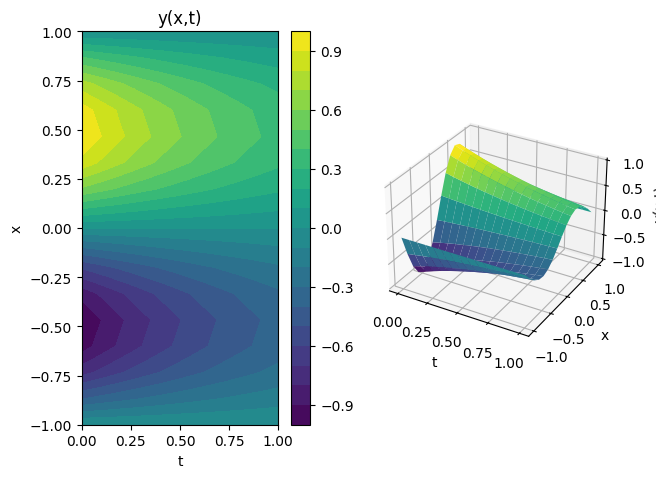

In [32]:
# plot exact PDE solution
Y_plot = Y_test_grid.squeeze(0).squeeze(0).detach().cpu()
plot3D(X_plot, T_plot, Y_plot)

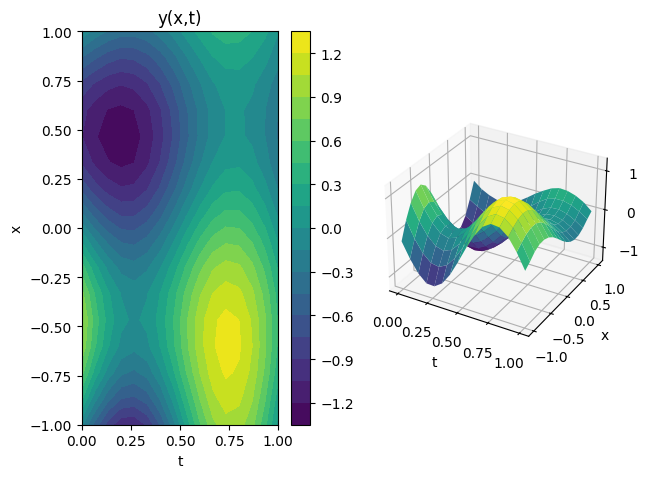

In [33]:
# plot residuals PINN - exact PDE
plot3D(X_plot, T_plot, y_fno - Y_plot)